## IMPORT LIBRARY
Kode tersebut digunakan untuk mengimpor library yang diperlukan dalam proses pengolahan citra, yaitu NumPy untuk pengolahan data array atau matriks, OpenCV untuk pemrosesan gambar, dan Matplotlib untuk menampilkan hasil visualisasi gambar.

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## KERNEL
Kode tersebut mendefinisikan empat kernel konvolusi dengan fungsi spesifik dalam pengolahan citra. Kernel sobelX dan sobelY merupakan matriks berukuran 3x3 yang masing-masing bertugas mendeteksi tepi vertikal dan tepi horizontal. Sementara itu, tigaXtiga (3x3) dan limaXlima (5x5) adalah box filter yang berisi nilai 1 secara seragam, berfungsi untuk melakukan penghalusan citra guna mengurangi noise, di mana kernel 5x5 menghasilkan efek blur yang jauh lebih kuat dibandingkan kernel 3x3 karena mencakup area piksel yang lebih luas.

In [20]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

tigaXtiga = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

limaXlima = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.float32)

## KONVOLUSI
Function konvolusi() digunakan untuk melakukan operasi konvolusi pada citra menggunakan kernel tertentu. Function ini biasanya dipakai dalam pengolahan citra untuk proses seperti filtering, blur, sharpening, maupun deteksi tepi. Hasil konvolusi akan menghasilkan citra baru berdasarkan perhitungan antara nilai piksel gambar dengan kernel yang diberikan.

In [21]:
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

## GARIS TEPI/EDGE
Function edge() digunakan untuk melakukan deteksi tepi pada citra menggunakan pasangan kernel horizontal dan vertikal. Function ini memanfaatkan operasi konvolusi untuk menghitung perubahan intensitas piksel pada dua arah tersebut, kemudian menggabungkannya untuk menghasilkan citra tepi. Hasil akhirnya berupa gambar yang menampilkan bagian tepi atau batas objek pada citra dengan intensitas yang telah dinormalisasi.

In [22]:
def edge(img, kernelx, kernely):
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

## RESIZE
Secara umum, kode tersebut berfungsi untuk mengubah ukuran panjang dan lebar sebuah gambar, baik untuk diperbesar maupun diperkecil. Cara kerjanya sangat sederhana, yaitu dengan membuat wadah gambar baru sesuai ukuran yang diminta, kemudian mengisi setiap titik pada wadah baru tersebut dengan menyalin warna dari titik yang posisinya paling bersesuaian pada gambar aslinya tanpa melakukan penyesuaian efek warna lainnya.

In [23]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

## THRESHOLD
Function threshold() digunakan untuk melakukan proses thresholding pada citra, yaitu mengubah gambar menjadi citra biner berdasarkan nilai ambang tertentu. Piksel yang memiliki nilai di atas threshold akan diubah menjadi putih, sedangkan piksel di bawah threshold akan diubah menjadi hitam.

In [24]:
def threshold(img, batas): 
    baris, kolom = img.shape 
    canvas = np.zeros_like(img, dtype=np.uint8) 
    for i in range(baris): 
        for j in range(kolom): 
            if(img[i,j] > batas): 
                canvas[i,j] = 255 
            elif(img[i,j] <= batas): 
                canvas[i,j] = 0 
    return canvas

## DILASI
Kode tersebut digunakan untuk melakukan proses dilasi pada citra digital, yaitu memperbesar atau menebalkan bagian objek pada gambar biner. Program bekerja dengan menyebarkan piksel putih berdasarkan bentuk kernel sehingga objek terlihat lebih besar dan celah kecil pada objek dapat tertutup. Operasi ini sering digunakan dalam pengolahan citra untuk memperjelas bentuk objek dan membantu proses deteksi atau analisis gambar.

In [25]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height//2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil

## EROSI
Kode tersebut digunakan untuk melakukan proses erosi pada citra digital, yaitu mengecilkan atau menipiskan bagian objek pada gambar biner. Program bekerja dengan memeriksa apakah area di sekitar piksel sesuai dengan bentuk kernel yang digunakan. Jika tidak sesuai, maka piksel objek akan dihilangkan. Operasi ini biasanya digunakan untuk menghapus noise kecil, memisahkan objek yang saling menempel, dan memperjelas bentuk objek pada proses pengolahan citra digital.

In [26]:
def erosi(image, kernel):
    img_height, img_width = image.shape
    k_height, k_width = kernel.shape
    
    center_y = k_height // 2
    center_x = k_width // 2
    
    hasil = np.zeros((img_height, img_width), dtype=np.uint8)
    
    for i in range(img_height):
        for j in range(img_width):
            
            cocok = True
            
            for k in range(k_height):
                for l in range(k_width):
                    
                    img_i = i + k - center_y
                    img_j = j + l - center_x
                    
                    if kernel[k, l] == 1:
                        if (img_i < 0 or img_i >= img_height or 
                            img_j < 0 or img_j >= img_width):
                            cocok = False
                            break
                        
                        if image[img_i, img_j] == 0:
                            cocok = False
                            break
                if not cocok:
                    break
            
            if cocok:
                hasil[i, j] = 255
                
    return hasil

## THINNING
Kode tersebut digunakan untuk melakukan proses thinning pada citra digital, yaitu menipiskan objek hingga menjadi kerangka atau garis tengahnya saja tanpa menghilangkan bentuk utama objek. Program bekerja dengan menghapus piksel tepi objek secara bertahap berdasarkan kondisi tertentu pada piksel tetangga di sekitarnya. Proses ini dilakukan berulang sampai tidak ada lagi piksel yang dapat dihapus. Operasi thinning sering digunakan pada pengolahan citra untuk analisis bentuk, pengenalan pola, tulisan tangan, sidik jari, dan ekstraksi kerangka objek.

In [27]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and
                    P2 * P4 * P6 == 0 and P4 * P6 * P8 == 0):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0
        hapus = []

        # STEP 2
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and
                    P2 * P4 * P8 == 0 and P2 * P6 * P8 == 0):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

## THICKENING
Kode tersebut digunakan untuk melakukan proses thickening pada citra digital, yaitu menebalkan atau memperbesar bagian objek pada gambar. Program bekerja dengan menjalankan operasi dilasi secara berulang sesuai jumlah iterasi yang ditentukan, sehingga objek akan semakin tebal mengikuti bentuk kernel yang digunakan. Operasi ini biasanya digunakan untuk memperjelas objek, memperkuat garis, dan menutup celah kecil pada citra digital.

In [28]:
def thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = dilasi(hasil, kernel) 
    return hasil

## MEMBACA, MENGUBAH, DAN MENAMPILKAN CITRA
Kode tersebut digunakan untuk melakukan tahapan dasar pengolahan citra digital pada gambar telapak tangan. Program dimulai dengan membaca gambar, mengubahnya menjadi citra grayscale, lalu mengubah ukurannya agar lebih seragam. Setelah itu dilakukan deteksi tepi menggunakan operator Sobel untuk menemukan batas atau kontur tangan, kemudian hasilnya diproses dengan threshold agar objek dan latar belakang terlihat lebih jelas dalam bentuk biner. Terakhir, seluruh hasil proses ditampilkan menggunakan matplotlib sehingga setiap tahap pengolahan citra dapat dibandingkan secara visual.

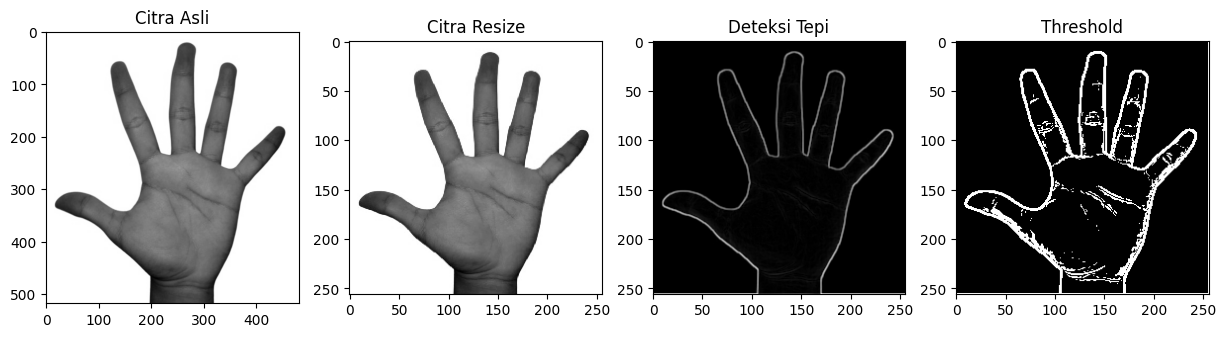

In [29]:
tangan = cv2.imread('tangan1.jpg')

tangan_gray = cv2.cvtColor(tangan, cv2.COLOR_BGR2GRAY)

tangan_resize = resize(tangan_gray, 256, 256)

tangan_sobel = edge(tangan_resize, sobelX, sobelY)

tangan_threshold = threshold(tangan_sobel, 10)

plt.figure(figsize=(15, 10))

plt.subplot(1,4,1)
plt.imshow(tangan_gray, cmap='gray')
plt.title('Citra Asli')

plt.subplot(1,4,2)
plt.imshow(tangan_resize, cmap='gray')
plt.title('Citra Resize')

plt.subplot(1,4,3)
plt.imshow(tangan_sobel, cmap='gray')
plt.title('Deteksi Tepi')

plt.subplot(1,4,4)
plt.imshow(tangan_threshold, cmap='gray')
plt.title('Threshold')

plt.show()

## PENGGUNAAN OPERASI MORFOLOGI 3X3 PADA CITRA THRESHOLD
Kode tersebut digunakan untuk menerapkan berbagai operasi morfologi pada citra telapak tangan yang telah melalui proses threshold. Program melakukan beberapa proses seperti dilasi untuk menebalkan objek, erosi untuk menipiskan objek, opening untuk menghilangkan noise kecil, closing untuk menutup celah pada objek, thinning untuk mendapatkan kerangka objek, thickening untuk mempertebal bentuk objek, serta gradient morfologi untuk menampilkan bagian tepi objek berdasarkan selisih antara dilasi dan erosi. Setelah semua proses selesai, hasil tiap operasi ditampilkan menggunakan matplotlib agar perbedaan efek dari masing-masing metode morfologi dapat dibandingkan secara visual.

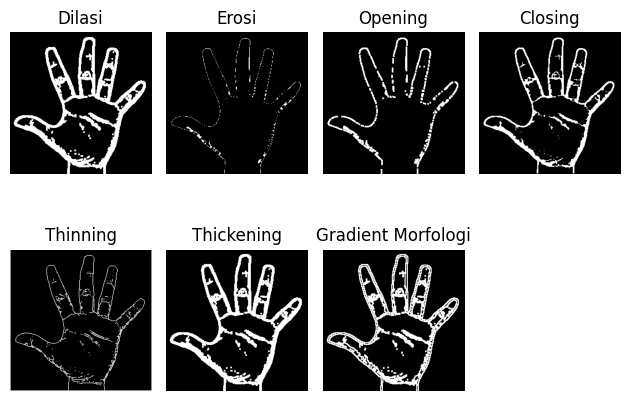

In [30]:
tangan_dilasi3 = dilasi(tangan_threshold, tigaXtiga)
tangan_erosi3 = erosi(tangan_threshold, tigaXtiga)
tangan_opening3 = dilasi(erosi(tangan_threshold, tigaXtiga), tigaXtiga)
tangan_closing3 = erosi(dilasi(tangan_threshold, tigaXtiga), tigaXtiga)
tangan_thinning3 = thinning(tangan_threshold)
tangan_thickening3 = thickening(tangan_threshold, tigaXtiga)
tangan_gradient_morph3 = np.clip(
    tangan_dilasi3.astype(np.int32) - tangan_erosi3.astype(np.int32),
    0,
    255
).astype(np.uint8)

plt.subplot(2,4, 1)
plt.imshow(tangan_dilasi3, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4, 2)
plt.imshow(tangan_erosi3, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4, 3)
plt.imshow(tangan_opening3, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4, 4)
plt.imshow(tangan_closing3, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4, 5)
plt.imshow(tangan_thinning3, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4, 6)
plt.imshow(tangan_thickening3, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4, 7)
plt.imshow(tangan_gradient_morph3, cmap='gray')
plt.title('Gradient Morfologi')
plt.axis('off')
plt.tight_layout()

## PENGGUNAAN OPERASI MORFOLOGI 5X5 PADA CITRA THRESHOLD
Kode tersebut digunakan untuk menerapkan berbagai operasi morfologi pada citra telapak tangan menggunakan kernel berukuran 5×5. Program melakukan proses dilasi, erosi, opening, closing, thinning, thickening, dan gradient morfologi untuk melihat perubahan bentuk objek setelah diproses dengan kernel yang lebih besar. Penggunaan kernel 5×5 membuat efek morfologi menjadi lebih kuat, seperti objek yang lebih tebal pada dilasi atau lebih tipis pada erosi. Setelah semua proses selesai, hasil setiap operasi ditampilkan menggunakan matplotlib agar perbedaan hasil pengolahan citra dapat diamati secara visual.

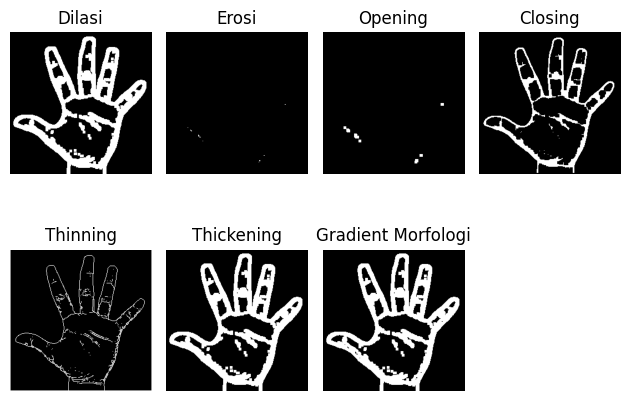

In [31]:


tangan_dilasi5 = dilasi(tangan_threshold, limaXlima)
tangan_erosi5 = erosi(tangan_threshold, limaXlima)
tangan_opening5 = dilasi(erosi(tangan_threshold, limaXlima), limaXlima)
tangan_closing5 = erosi(dilasi(tangan_threshold, limaXlima), limaXlima)
tangan_thinning5 = thinning(tangan_threshold)
tangan_thickening5 = thickening(tangan_threshold, limaXlima)
tangan_gradient_morph5 = np.clip(
    tangan_dilasi5.astype(np.int32) - tangan_erosi5.astype(np.int32),
    0,
    255
).astype(np.uint8)

plt.subplot(2,4, 1)
plt.imshow(tangan_dilasi5, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4, 2)
plt.imshow(tangan_erosi5, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4, 3)
plt.imshow(tangan_opening5, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4, 4)
plt.imshow(tangan_closing5, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4, 5)
plt.imshow(tangan_thinning5, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4, 6)
plt.imshow(tangan_thickening5, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4, 7)
plt.imshow(tangan_gradient_morph5, cmap='gray')
plt.title('Gradient Morfologi')
plt.axis('off')
plt.tight_layout()

## KOMBINASI 2 PROSES MORFOLOGI
Kode tersebut digunakan untuk membandingkan hasil penggabungan beberapa operasi morfologi pada citra telapak tangan. Program melakukan kombinasi proses seperti Opening + Closing, Closing + Opening, Opening + Dilasi, serta Closing + Erosi untuk melihat bagaimana urutan dan jenis operasi memengaruhi bentuk akhir objek pada citra. Setiap kombinasi memberikan efek yang berbeda, misalnya membersihkan noise, menutup celah, menebalkan, atau menipiskan objek. Hasil dari masing-masing proses kemudian ditampilkan menggunakan matplotlib agar perbedaan perubahan citra dapat diamati secara visual.

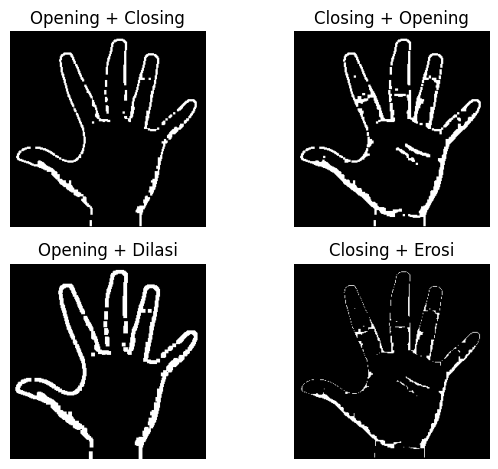

In [32]:
tangan_openclose = erosi(dilasi(tangan_opening3, tigaXtiga), tigaXtiga)
tangan_closeopen = dilasi(erosi(tangan_closing3, tigaXtiga), tigaXtiga)
tangan_opendilasi = dilasi(tangan_opening3, tigaXtiga)
tangan_closeerosi = erosi(tangan_closing3, tigaXtiga)

plt.subplot(2,2,1)
plt.imshow(tangan_openclose, cmap='gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2,2, 2)
plt.imshow(tangan_closeopen, cmap='gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2,2, 3)
plt.imshow(tangan_opendilasi, cmap='gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2,2, 4)
plt.imshow(tangan_closeerosi, cmap='gray')
plt.title('Closing + Erosi')
plt.axis('off')
plt.tight_layout()

## EKSPLORASI MANDIRI
Untuk mendapatkan hasil seperti dibawah, ada beberapa tahapan yang dilakukan, Opsional: Gunakan resize untuk ukuran citra:
1. Citra telapak tangan dibaca menggunakan OpenCV.
2. Citra diubah menjadi grayscale agar proses pengolahan lebih mudah karena hanya menggunakan intensitas warna abu-abu.
3. Dilakukan deteksi tepi menggunakan operator Sobel untuk menemukan garis tepi dan kontur tangan.
4. Hasil deteksi tepi kemudian dithreshold agar gambar menjadi biner hitam putih sehingga objek tangan terlihat lebih jelas.
5. Setelah itu dilakukan operasi morfologi closing dengan kernel 3×3 untuk menutup celah kecil dan menyambungkan bagian tepi yang terputus.
6. Terakhir, dilakukan lagi deteksi tepi Sobel pada hasil closing sehingga kontur telapak tangan dan detail didalamnya menjadi lebih jelas.

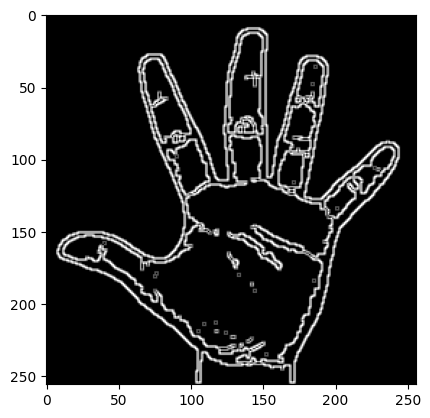

In [33]:
tangan_final = edge(tangan_closing3, sobelX, sobelY)
plt.imshow(tangan_final, cmap='gray')
plt.show()

## ANALISIS PERBANDINGAN SEBELUM, SETELAH MORFOLOGI 3 X 3, DAN SETELAH MORFOLOGI 5 X 5
#### Sebelum Morfologi: Menampilkan citra asli dalam bentuk grayscale, kemudian diresize ukurannya menjadi 256 x 256. Setelah itu, dilakukan deteksi tepi menggunakan operator Sobel untuk mendeteksi tepi telapak tangan menjadi putih, sedangkan yang lainnya hitam. Terakhir, dilakukan thresholding untuk mengubah grayscale jadi biner hitam putih. Yang dari awal terlihat jelas telapak tangan menjadi sebuah citra hitam putih saja

#### Setelah Morfologi 3 X 3: Dilakukan tes pada hasil citra thresholding dengan kernel 3 X 3 kecuali operasi Thinning, tes yang dilakukan antara lain dilasi, erosi, opening, closing, thickening, dan gradient morfologi. Pada Dilasi, terjadi perbesaran area objek pada citra biner sehingga hasil citra menebal. Pada Erosi, terjadi penipisan area objek pada citra biner sehingga menghasilkan citra tipis dan hilangnya detail garis pada telapak tangan dari citra hasil thresholding. Pada Opening, terjadi proses menghilangkan noise kecil atau titik putih kecil di background sehingga banyak detail hilang pada telapak tangan. Pada Closing, terjadi proses menutup lubang kecil di dalam objek sehingga detail detail pada telapak tangan bergabung menjadi 1. Pada Thinning, terjadi penipisan citra hingga menjadi seperti kerangka skeleton. Pada Thickening, terjadi proses penebalan sehingga hasil citra menjadi sangat tebal. Pada Gradient Morfologi, menghasilkan tepi atau kontur objek dari citra biner karena adanya pengurangan dari operasi dilasi dengan erosi.

#### Setelah Morfologi 5 X 5: Dilakukan tes pada hasil citra thresholding dengan kernel 3 X 3 kecuali operasi Thinning, tes yang dilakukan antara lain dilasi, erosi, opening, closing, thickening, dan gradient morfologi. Pada Dilasi, terjadi perbesaran area objek pada citra biner sehingga hasil citra menebal, hasilnya lebih tebal daripada morfologi 3 X 3 dengan kernel 3 X 3. Pada Erosi, terjadi penipisan area objek pada citra biner sehingga menghasilkan citra tipis bahkan hilangnya tepi pada telapak tangan, menghasilkan sedikit titik titik kecil sisa Erosi. Pada Opening, terjadi proses menghilangkan noise kecil atau titik putih kecil di background sehingga banyak detail hilang pada telapak tangan, untuk detail yang hilang lebih banyak dibandingan pada morfologi dengan kernel 3 X 3. Pada Closing, terjadi proses menutup lubang kecil di dalam objek sehingga detail detail pada telapak tangan bergabung menjadi 1, terlihat menggunakan kernel 5 X 5 menyebabkan lubang lubang kecil lebih banyak ditutup sehingga hasilnya lebih tebal daripada yang menggunakan kernel 5 X 5. Pada Thinning, terjadi penipisan citra hingga menjadi seperti kerangka skeleton, ini sama seperti sebelumnya karena tidak menggunakan kernel apapun. Pada Thickening, terjadi proses penebalan sehingga hasil citra menjadi sangat tebal daripada menggunakan kernel 3 X 3. Pada Gradient Morfologi, menghasilkan tepi atau kontur objek dari citra biner lebih tebal daripada menggunakan kernel 3 X 3.

## ANALISIS KOMBINASI 2 PROSES MORFOLOGI DENGAN KERNEL 3 X 3
#### Opening + Closing: Pada awalnya hasil citra yang sudah dilakukan Opening menghasilkan citra dengan detail yang banyak hilang dan hanya menyisakan garis tepi saja. Setelah digabungkan dengan Closing menghasilkan citra dengan tambahan detail titik titik kecil dalam telapak tangan dan garis tepi menjadi semakin terlihat jelas daripada citra awal.

#### Closing + Opening
Kombinasi ini diawali dengan proses Opening yang efektif menghilangkan noise berupa titik-titik putih kecil di luar citra utama, kemudian dilanjutkan dengan Closing untuk menutup lubang-lubang kecil di dalam citra. Dibandingkan dengan operasi Opening tunggal yang membuat beberapa garis tepi menjadi terputus, penambahan Closing setelahnya berhasil menyambungkan kembali garis-garis yang terputus. Hasilnya, bentuk citra tangan tetap ada, ketebalan garis batas terlihat cukup rata dan mendekati citra aslinya.

####  Opening + Closing
Closing dilakukan terlebih dahulu untuk mengisi celah dan lubang kecil pada garis tepi, lalu diikuti dengan Opening untuk membersihkan noise di latar belakang. Garis-garis tepinya masih terjaga. Tetapi, jika dibandingkan dengan operasi tunggal, melakukan Closing terlebih dahulu dapat menyebabkan beberapa noise yang menempel dekat dengan batas tepi objek ikut menebal dan menyatu dengan objek utama, sehingga saat proses Opening dilakukan, noise tersebut tidak ikut terhapus.

#### Opening + Dilasi
Citra terlebih dahulu dibersihkan dari noise melalui proses Opening, kemudian secara keseluruhan objek dipertebal menggunakan operasi Dilasi. Dibandingkan dengan operasi Dilasi tunggal, hasil kombinasi ini jauh lebih bersih dari noise di latar belakang, karena noise tersebut sudah dihilangkan sebelum sempat diperbesar oleh dilasi. Jika dibandingkan dengan operasi Opening tunggal, garis batas tepi tangan menjadi jauh lebih tebal. Tetapi, terjadinya penebalan pada seluruh garis tepi tangan.

#### Closing + Erosi
Kombinasi terakhir bekerja dengan cara merapatkan dan mengisi celah-celah pada citra terlebih dahulu melalui operasi Closing, yang kemudian dilanjutkan dengan penipisan garis batas tepi melalui operasi Erosi. Dibandingkan dengan Erosi tunggal yang memutus garis tepi citra, kombinasi ini mempertahankan garis tepi dengan baik karena celah-celah sudah ditutup sebelumnya. Dibandingkan dengan operasi Closing tunggal, ketebalan objek mengalami pengurangan. Bentuk dasar citra tangan dapat dikenal, noise berupa lubang pada telapak tangan sedikit, dan batas objek terlihat tajam meskipun garis batasnya menjadi sangat tipis.
